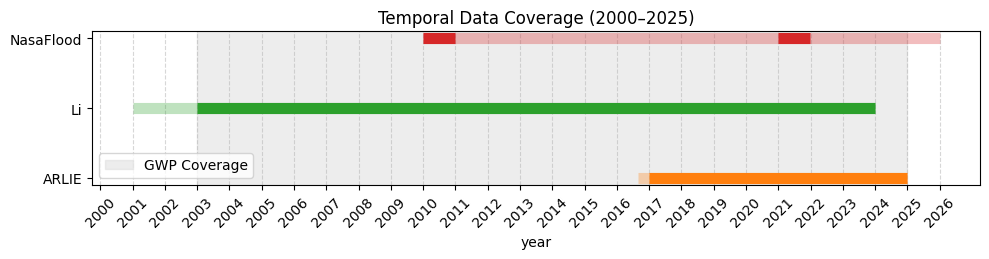

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Daten
data = [
    ("GWP",       "01.01.2003", "31.12.2024", None, None),
    ("ARLIE",     "01.09.2016", "31.12.2024", "01.01.2017", "31.12.2024"),
    ("Li et al",        "01.01.2001", "31.12.2023", "01.01.2003", "31.12.2023"),
    ("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2010", "31.12.2010"),  # volle Abdeckung + genutzte Jahre
]

# NasaFlood hat zwei Nutzzeiträume – erweitern:
# du kannst mehrere Einträge hinzufügen, um mehrere dunkle Segmente zu zeichnen
data.append(("NasaFlood", "01.01.2010", "31.12.2025", "01.01.2021", "31.12.2021"))


df = pd.DataFrame(data, columns=["Dataset", "Start1", "End1", "Start2", "End2"])

# Datumsparsing
for col in ["Start1", "End1", "Start2", "End2"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Farben
colors = {
    "ARLIE": "#ff7f0e",
    "Li": "#2ca02c",
    "NasaFlood": "#d62728",
}


# Filtere die Datasets ohne GWP
datasets = [d for d in df["Dataset"].unique() if d != "GWP"]


# Plot
fig, ax = plt.subplots(figsize=(10, 2.7))

# === GWP als grauer Hintergrund ===
gwp_row = df[df["Dataset"] == "GWP"].iloc[0]
ax.axvspan(gwp_row["Start1"], gwp_row["End1"], color="lightgrey", alpha=0.4, label="GWP Coverage")

# === Andere Datensätze ===
for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    color = colors.get(dataset, "grey")

    # hell: gesamte Abdeckung
    full_start = subset["Start1"].min()
    full_end = subset["End1"].max()
    ax.plot(
        [full_start, full_end],
        [i, i],
        lw=8,
        alpha=0.3,
        color=color,
        solid_capstyle="butt"
    )

    # dunkel: tatsächliche Zeiträume
    for _, row in subset.iterrows():
        if pd.notna(row["Start2"]) and pd.notna(row["End2"]):
            ax.plot(
                [row["Start2"], row["End2"]],
                [i, i],
                lw=8,
                alpha=1.0,
                color=color,
                solid_capstyle="butt"
            )

# y-Ticks & Labels korrekt setzen
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)


# X-Achse: jedes Jahr
years = pd.date_range("2000-01-01", "2026-01-01", freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([y.year for y in years], rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.set_xlabel("year")
ax.set_title("Temporal Data Coverage (2000–2025)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
